# Анализ аудитории витуберов

#### Импорт всего нужного

In [1]:
import sys
sys.path.insert(1, '../util/')

from data import UserData, FollowData, FollowerData
from userdata import get_userdata, get_userdata_by_login
from followers import get_followers

import numpy as np
import os
import csv
from datetime import datetime
from typing import Optional, List, Tuple, Dict
from concurrent.futures import ThreadPoolExecutor, as_completed

## Грузим фолловеров у витуберов

In [2]:
VTUBERS_LIST_FILE_PATH = "./data/vtubers.txt"
VTUBERS = set()

with open(VTUBERS_LIST_FILE_PATH, 'r') as data_file:
    for line in data_file.readlines():
        if line.startswith("#"): # comment:
            continue
        VTUBERS.add(line.lower().strip())

In [3]:
# Check if all vtubers exists
counter = 0
for vtuber in VTUBERS:
    counter += 1
    print(f"[{counter}/{len(VTUBERS)}] Check vtuber {vtuber}")
    assert get_userdata_by_login(vtuber) is not None

[1/203] Check vtuber arr1su
[2/203] Check vtuber mamilokuchii
[3/203] Check vtuber nekisekai
[4/203] Check vtuber maria_ai_
[5/203] Check vtuber qchaan_9
[6/203] Check vtuber persieq
[7/203] Check vtuber noelvtuber_
[8/203] Check vtuber moereira
[9/203] Check vtuber banshameow
[10/203] Check vtuber somber_chan
[11/203] Check vtuber io_cow
[12/203] Check vtuber poliamaki
[13/203] Check vtuber charlotte__ch
[14/203] Check vtuber owlielowi
[15/203] Check vtuber folly_anaya
[16/203] Check vtuber quinella_admin
[17/203] Check vtuber nyapuru
[18/203] Check vtuber miruku_hoshi
[19/203] Check vtuber amelialavert
[20/203] Check vtuber vvurst_exe
[21/203] Check vtuber gabykuru
[22/203] Check vtuber alexstrawho
[23/203] Check vtuber moonseere
[24/203] Check vtuber miroishiko
[25/203] Check vtuber axilissa
[26/203] Check vtuber fumm_y
[27/203] Check vtuber yourhappywaifu
[28/203] Check vtuber regendaryone
[29/203] Check vtuber ayyuri
[30/203] Check vtuber mad_demian
[31/203] Check vtuber tressa_ri

In [4]:
print(f"Loaded {len(VTUBERS)} vtubers")

Loaded 203 vtubers


### Онлайн загрузка

In [5]:
NUM_WORKERS = 8 # Set up for your processor and to prevent from ddos protection


def load_followers_execution(vtuber_login: str) -> Tuple[str, Optional[List[FollowerData]]]:
    return vtuber_login, get_followers(vtuber_login, logging=True)


# Fast load
vtuber_followers = {}
with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
    futures = []

    for vtuber in VTUBERS:
        future = executor.submit(load_followers_execution, vtuber_login=vtuber)
        futures.append(future)
    
    for future in as_completed(futures):
        vtuber_login, followers_result = future.result()
        print(f"Got \"{vtuber_login}\" result")
        vtuber_followers[vtuber_login] = followers_result

[LOG:arr1su] Loaded 0 results
[LOG:mamilokuchii] Loaded 0 results
[LOG:nekisekai] Loaded 0 results
[LOG:maria_ai_] Loaded 0 results
[LOG:qchaan_9] Loaded 0 results
[LOG:persieq] Loaded 0 results
[LOG:noelvtuber_] Loaded 0 results
[LOG:moereira] Loaded 0 results
[LOG:persieq] Loaded 100 results
[LOG:arr1su] Loaded 100 results
[LOG:maria_ai_] Loaded 100 results
[LOG:moereira] Loaded 100 results
[LOG:qchaan_9] Loaded 100 results
[LOG:mamilokuchii] Loaded 100 results
[LOG:noelvtuber_] Loaded 100 results
[LOG:nekisekai] Loaded 100 results
[LOG:persieq] Loaded 200 results
[LOG:arr1su] Loaded 200 results
[LOG:maria_ai_] Loaded 200 results
[LOG:moereira] Loaded 200 results
[LOG:mamilokuchii] Loaded 200 results
[LOG:qchaan_9] Loaded 200 results
[LOG:noelvtuber_] Loaded 200 results
[LOG:nekisekai] Loaded 200 results
[LOG:persieq] Loaded 300 results
[LOG:arr1su] Loaded 300 results
[LOG:moereira] Loaded 300 results
[LOG:mamilokuchii] Loaded 300 results
[LOG:qchaan_9] Loaded 300 results
[LOG:nekise

In [7]:
for vtuber in VTUBERS:
    if vtuber_followers[vtuber] is None:
        print(vtuber, None)
    else:
        print(vtuber, len(vtuber_followers[vtuber]))

arr1su 1443
mamilokuchii 17174
nekisekai 12849
maria_ai_ 3813
qchaan_9 27558
persieq 2127
noelvtuber_ 2354
moereira 17024
banshameow 14483
somber_chan 2476
io_cow 1979
poliamaki 2862
charlotte__ch 3011
owlielowi 5360
folly_anaya 3415
quinella_admin 15398
nyapuru 12733
miruku_hoshi 4625
amelialavert 3363
vvurst_exe 1109
gabykuru 1663
alexstrawho 13458
moonseere 3788
miroishiko 1340
axilissa 1231
fumm_y 938
yourhappywaifu 837
regendaryone 4185
ayyuri 2255
mad_demian 4519
tressa_ri 1435
miyuchiiro 1935
amalia_goddes 4580
manarenewal 11316
yuresss 7467
piwochan 6485
yuttwl17 835
nubchann 15096
yosyachii 2038
mizukkka 4163
bready_xo 5512
awful_queen 3629
hanikachan 5158
boopa 13370
solemuri 4162
haruweichan 1288
kashtan_mp4 2982
moonspidy 3558
mokimioki 8465
hovvney 1395
sheeppyoz 884
lilanei 6309
sati_akura 33707
froggytyan 3505
echidnaya 3592
mirednesy 8452
tomoesin 3919
nyamuras 28012
vernirra 18474
gammabadart 3292
cirnostrong 730
hattiezazu 3081
itsmoriko 7814
ranko_nielson 1142
ifrit_

### Кеширование результатов

In [8]:
def get_cache_path():
    current_date = datetime.now()

    return os.path.join("data/", 
                        ".temp/",
                        f"followers_{current_date.year}_{current_date.month}_{current_date.day}.txt")

In [9]:
def cache_followers_data(vtuber_followers: Dict[str, Optional[List[FollowerData]]]):
    with open(get_cache_path(), 'w') as cache_file:
        csvwriter = csv.writer(cache_file, delimiter=',')
        csvwriter.writerow(["vtuber", "login", "created_at", "followed_at"])

        for (vtuber, value) in vtuber_followers.items():
            if value is None:
                print("[WARNING]", "No data provided for the vtuber", vtuber)
            else:
                for follower_data in value:
                    csvwriter.writerow([vtuber, follower_data.name, str(follower_data.created_at), str(follower_data.followed_at)])

In [10]:
cache_followers_data(vtuber_followers)

#### Загрузка закешированных результатов

In [11]:
def load_followers_cache(filepath: str) -> Dict[str, List[FollowerData]]:
    result = {}

    with open(filepath, 'r') as cache_file:
        csvreader = csv.DictReader(cache_file, delimiter=',')
        # csvreader.writerow(["vtuber", "login", "created_at", "followed_at"])

        for row in csvreader:
            vtuber = row['vtuber']
            follower_data = FollowerData(row['login'],
                                         datetime.fromisoformat(row['created_at']),
                                         datetime.fromisoformat(row['followed_at']))
            if vtuber not in result.keys():
                result[vtuber] = []
            result[vtuber].append(follower_data)
    
    return result

## Обрабатываем полученный данные

In [12]:
data = load_followers_cache("./data/.temp/followers_2025_10_31.txt")

In [13]:
print("vtuber,followers,existing_followers")
for (vtuber, followers) in data.items():
    print(vtuber, len(followers), len(list(filter(lambda el: el.name, followers))), sep=",")

vtuber,followers,existing_followers
arr1su,1443,1441
persieq,2127,2127
noelvtuber_,2354,2354
maria_ai_,3813,3811
io_cow,1979,1978
somber_chan,2476,2474
poliamaki,2862,2862
charlotte__ch,3011,3011
owlielowi,5360,5359
folly_anaya,3415,3414
nekisekai,12849,12846
miruku_hoshi,4625,4623
vvurst_exe,1109,1109
amelialavert,3363,3362
banshameow,14483,14481
moereira,17024,17019
mamilokuchii,17174,17009
gabykuru,1663,1663
axilissa,1231,1231
miroishiko,1340,1339
fumm_y,938,938
yourhappywaifu,837,837
moonseere,3788,3787
ayyuri,2255,2254
nyapuru,12733,12732
tressa_ri,1435,1435
regendaryone,4185,4184
quinella_admin,15398,15394
miyuchiiro,1935,1935
mad_demian,4519,4513
yuttwl17,835,835
yosyachii,2038,2036
amalia_goddes,4580,4578
qchaan_9,27558,27556
piwochan,6485,6485
alexstrawho,13458,13458
yuresss,7467,7465
mizukkka,4163,4161
awful_queen,3629,3629
haruweichan,1288,1288
bready_xo,5512,5499
kashtan_mp4,2982,2982
manarenewal,11316,11316
solemuri,4162,4160
hanikachan,5158,5157
sheeppyoz,884,883
hovvney,

In [14]:
# Check if data is complete
for vtuber in VTUBERS:
    assert vtuber in data.keys()

### Анализ общей аудитории

In [15]:
import matplotlib.pyplot as plt

#### Анализ подписок

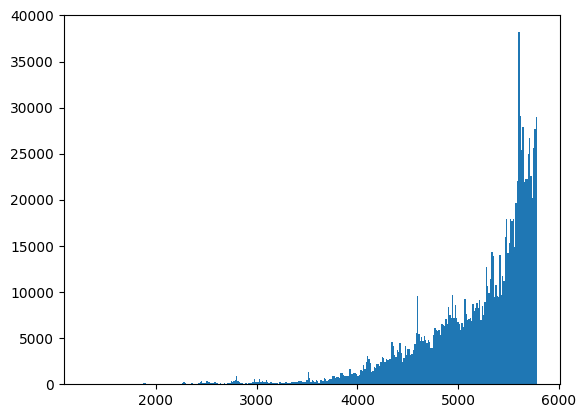

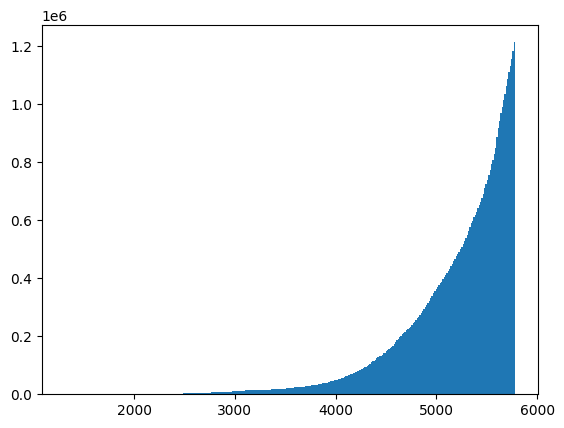

In [16]:
sunce_date = datetime.fromisoformat("2010-01-01 00:00:00.000000+00:00")
auditory_data = []
for vtuber in VTUBERS:
    followers = data[vtuber]
    for follower in followers:
        auditory_data.append(follower)

auditory_data = list(map(lambda viewer: viewer.followed_at, auditory_data))
auditory_data = list(map(lambda follow_date: follow_date - sunce_date, auditory_data))
auditory_data = list(map(lambda follow_timedelta: follow_timedelta.days, auditory_data))
auditory_data = np.array(auditory_data)

plt.hist(auditory_data, bins="auto", log=False, cumulative=False)
plt.show() 
plt.hist(auditory_data, bins="auto", log=False, cumulative=True)
plt.show() 

Тенденция к росту, однозначно, есть.

Хотя есть два момента, которые очень инетересные, первый около 4600 дня, второй - с апреля этого года.

* Первый обусловлен следующим: `yumekomoore` и `sati_akura` резко взлетели
* Второй обусловлен следующим: `xKamysh` резко взлетела 

#### Пруф для первого момента

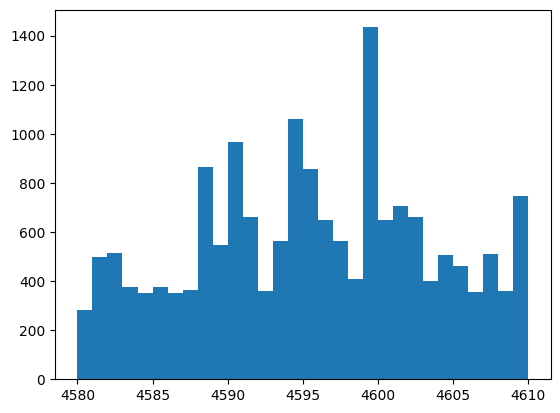

In [17]:
sunce_date = datetime.fromisoformat("2010-01-01 00:00:00.000000+00:00")
auditory_data = []
for vtuber in VTUBERS:
    followers = data[vtuber]
    for follower in followers:
        auditory_data.append(follower)

auditory_data = list(map(lambda viewer: viewer.followed_at, auditory_data))
auditory_data = list(map(lambda follow_date: follow_date - sunce_date, auditory_data))
auditory_data = list(map(lambda follow_timedelta: follow_timedelta.days, auditory_data))
auditory_data = np.array(auditory_data)

plt.hist(auditory_data, bins="auto", log=False, cumulative=False, range=(4580, 4610))
plt.show() 

In [19]:
sunce_date = datetime.fromisoformat("2010-01-01 00:00:00.000000+00:00")
auditory_data = []
for vtuber in VTUBERS:
    followers = data[vtuber]
    for follower in followers:
        auditory_data.append((vtuber, follower))

auditory_data = list(filter(lambda viewer: (viewer[1].followed_at - sunce_date).days in range(4580, 4610), auditory_data))
counters = {}
for dt in auditory_data:
    counters[dt[0]] = counters.get(dt[0], 0) + 1
print(auditory_data[100][1].followed_at)

for (k, v) in sorted(counters.items(), key=lambda el: el[1], reverse=True)[:10]:
    print(k, v)

2022-08-01 06:13:04+00:00
yumekomoore 3525
sati_akura 3310
kurisu 1585
quinella_admin 713
nyamuras 438
vernirra 381
fropsya 307
holographicvt 299
moereira 289
mamilokuchii 280


#### Пруф для второго момента

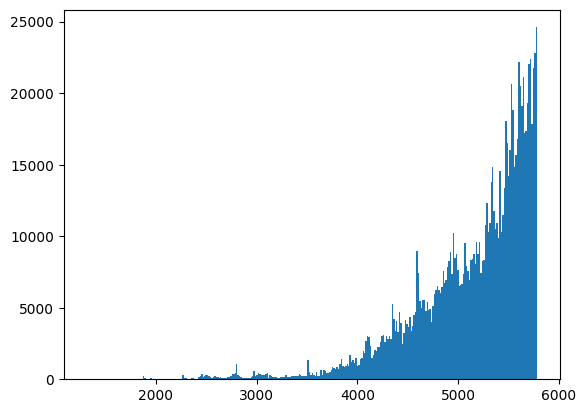

In [20]:
IGNORED_VTUBERS = ['xkamysh', 'qchaan_9', 'rera_seal']

sunce_date = datetime.fromisoformat("2010-01-01 00:00:00.000000+00:00")
auditory_data = []
for vtuber in VTUBERS:
    if vtuber in IGNORED_VTUBERS:
        continue
    
    followers = data[vtuber]
    for follower in followers:
        auditory_data.append(follower)

auditory_data = list(map(lambda viewer: viewer.followed_at, auditory_data))
auditory_data = list(map(lambda follow_date: follow_date - sunce_date, auditory_data))
auditory_data = list(map(lambda follow_timedelta: follow_timedelta.days, auditory_data))
auditory_data = np.array(auditory_data)

plt.hist(auditory_data, bins="auto", log=False, cumulative=False)
plt.show() 

### Анализ роста аудитории

Счетчик уникальных фолловов (то есть не учитываются второй, третий и т.д. фолловы от одного и того же человека)

In [21]:
sunce_date = datetime.fromisoformat("2010-01-01 00:00:00.000000+00:00")
auditory_data = {}
for vtuber in VTUBERS:
    followers = data[vtuber]
    for follower in followers:
        if follower.name not in auditory_data.keys():
            auditory_data[follower.name] = follower.followed_at
        auditory_data[follower.name] = min(auditory_data[follower.name], follower.followed_at)

auditory_data = auditory_data.values()
auditory_data = list(map(lambda follow_date: follow_date - sunce_date, auditory_data))
auditory_data = list(map(lambda follow_timedelta: follow_timedelta.days, auditory_data))
auditory_data = np.array(auditory_data)

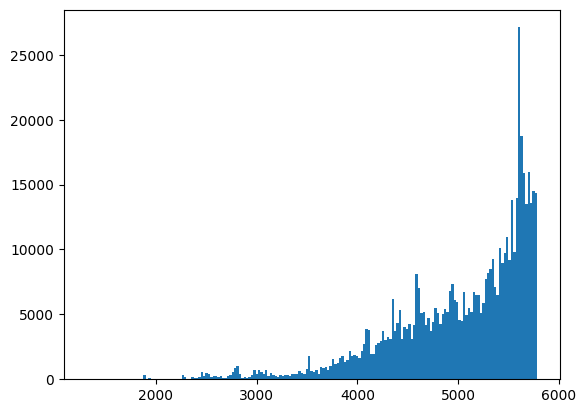

In [24]:
plt.hist(auditory_data, bins="auto", log=False, cumulative=False)
plt.show() 

### Уникальность витуберов

Посмотрим, какая часть аудитории витубера смотрит только его 

In [25]:
follows_by_user = {}
for vtuber in VTUBERS:
    for follow_data in data[vtuber]:
        if follow_data.name not in follows_by_user.keys():
            follows_by_user[follow_data.name] = []    
        follows_by_user[follow_data.name].append((vtuber, follow_data))
print(len(follows_by_user.keys()))

555899


In [26]:
unique_users = list(filter(lambda fd: len(fd[1]) == 1, follows_by_user.items()))
print(len(unique_users))

402413


In [27]:
vtuber_unique_followers_counter = {}
for (user, following) in unique_users:
    vtuber_name = following[0][0]
    vtuber_unique_followers_counter[vtuber_name] = vtuber_unique_followers_counter.get(vtuber_name, 0) + 1
for (k, v) in sorted(vtuber_unique_followers_counter.items(), key=lambda el: el[1] / len(data[el[0]]), reverse=True):
    print(k, f"{v}/{len(data[k])}", f"{v * 100 // len(data[k])}%")

mad_demian 3855/4519 85%
bready_xo 4625/5512 83%
natakodo 18171/22059 82%
lastglance_ 3371/4250 79%
gishichi 886/1264 70%
kashtan_mp4 2030/2982 68%
nyapuru 8657/12733 67%
mukubae 1613/2429 66%
boopa 8545/13370 63%
linamyth 4732/7542 62%
ananastya_nastya 6511/10562 61%
amikirisan 5176/8408 61%
piwochan 3942/6485 60%
naxajlka 2142/3588 59%
lightfoxmanga 4903/8276 59%
quinella_admin 8864/15398 57%
vernirra 10568/18474 57%
planyach 26256/46423 56%
nekisekai 7131/12849 55%
nnstreamercha 2546/4724 53%
mamilokuchii 8751/17174 50%
yumekomoore 15773/31344 50%
kwakusha228 1225/2441 50%
goosekina 1569/3151 49%
grettach 8574/17257 49%
yuresss 3403/7467 45%
nitesmi 891/1967 45%
hattiezazu 1368/3081 44%
akane_iwawwa 7024/15881 44%
blinchii 1894/4361 43%
maria_ai_ 1647/3813 43%
perolya 3404/7907 43%
pandochka_7 1656/3884 42%
miruku_hoshi 1941/4625 41%
usbsushi 1483/3590 41%
grees_greeck 1761/4294 41%
aerochannelekat 489/1196 40%
sati_akura 13764/33707 40%
xkamysh 33361/82712 40%
kurisu 10490/27232 38

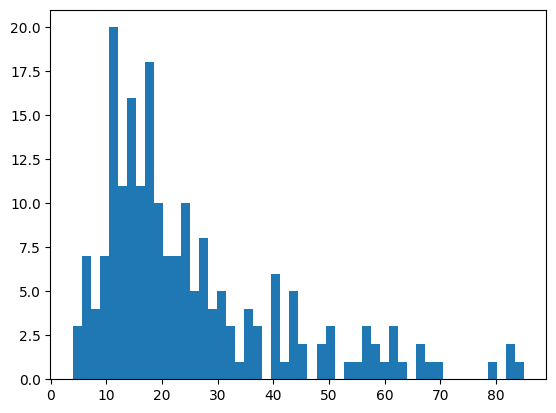

In [28]:
plt.hist(list(map(lambda el: int(el[1] * 100 / len(data[el[0]])), vtuber_unique_followers_counter.items())), bins=50)
plt.show()

| Vtuber | Statistics | Description |
| --- | --- | --- |
| mad_demian | 3855/4519 85% | в хиатусе |
| bready_xo | 4625/5512 83% | в хиатусе |
| natakodo | 18171/22059 82% | в хиатусе |
| lastglance_ | 3371/4250 79% | в хиатусе |
| gishichi | 886/1264 70% | англо витубер??? |
| kashtan_mp4 | 2030/2982 68% | Ich weiß nicht |
| nyapuru | 8657/12733 67% | мужыыыыык |
| mukubae | 1613/2429 66% | в хиатусе |
| boopa | 8545/13370 63% | Ich weiß nicht |
| linamyth | 4732/7542 62% | в хиатусе |
| ananastya_nastya | 6511/10562 61% | Лига легендер |
| amikirisan | 5176/8408 61% | Ich weiß nicht |
| piwochan | 3942/6485 60% | Ich weiß nicht |
| naxajlka | 2142/3588 59% | Ich weiß nicht |
| lightfoxmanga | 4903/8276 59% | мужыыыыык |
| quinella_admin | 8864/15398 57% | Ich weiß nicht |
| vernirra | 10568/18474 57% | Ich weiß nicht |
| planyach | 26256/46423 56% | Ich weiß nicht |
| nekisekai | 7131/12849 55% | Ich weiß nicht |
| nnstreamercha | 2546/4724 53% | мужыыыыык |
| mamilokuchii | 8751/17174 50% | Лигалегендер, любимый у дедпи |
| yumekomoore | 15773/31344 50% | Ich weiß nicht |

### Кластеризация витуберов